<a href="https://colab.research.google.com/github/adaryass/Applied-Mathematics-and-Finance/blob/main/Project_Option_Pricing_Yassir_and_Hugo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Librairies
from scipy.stats import norm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from pickle import LONG_BINGET

# Long Call,  Short Call, Long Put, Short Put

### I - Les positions fondamentales sur les options

Comprendre les profils de profit et de perte des options de base est crucial pour élaborer des stratégies d'investissement. Voici une explication des quatre positions principales :

*   **Long Call (Achat d'un Call)** :
    *   **Description** : L'acheteur d'un *call* a le droit, mais non l'obligation, d'acheter l'actif sous-jacent à un prix d'exercice (strike) fixé avant ou à la date d'échéance. Cette position est prise lorsque l'on anticipe une **hausse significative** du prix de l'actif.
    *   **Profil de profit** : Le profit potentiel est illimité si le prix de l'actif augmente fortement au-dessus du prix d'exercice. La perte est limitée au montant de la prime payée pour l'option.
    *   **ITM/OTM** : L'option est **In-The-Money (ITM)** si le prix de l'actif (S) est supérieur au prix d'exercice (K) (S > K). Elle est **Out-of-The-Money (OTM)** si S < K.

*   **Short Call (Vente d'un Call)** :
    *   **Description** : Le vendeur d'un *call* a l'obligation de vendre l'actif sous-jacent au prix d'exercice si l'acheteur exerce l'option. Cette position est prise lorsque l'on anticipe une **stabilité ou une légère baisse** du prix de l'actif.
    *   **Profil de profit** : Le profit est limité à la prime reçue lors de la vente de l'option. La perte potentielle est illimitée si le prix de l'actif augmente fortement, car le vendeur doit acheter l'actif au prix du marché (élevé) pour le revendre au prix d'exercice (plus bas).
    

*   **Long Put (Achat d'un Put)** :
    *   **Description** : L'acheteur d'un *put* a le droit, mais non l'obligation, de vendre l'actif sous-jacent à un prix d'exercice fixé avant ou à la date d'échéance. Cette position est prise lorsque l'on anticipe une **baisse significative** du prix de l'actif.
    *   **Profil de profit** : Le profit potentiel est élevé si le prix de l'actif chute fortement en dessous du prix d'exercice (le profit maximum est limité à K moins la prime, car le prix de l'actif ne peut pas être inférieur à zéro). La perte est limitée au montant de la prime payée.
    *   **ITM/OTM** : L'option est **In-The-Money (ITM)** si le prix de l'actif (S) est inférieur au prix d'exercice (K) (S < K). Elle est **Out-of-The-Money (OTM)** si S > K.

*   **Short Put (Vente d'un Put)** :
    *   **Description** : Le vendeur d'un *put* a l'obligation d'acheter l'actif sous-jacent au prix d'exercice si l'acheteur exerce l'option. Cette position est prise lorsque l'on anticipe une **stabilité ou une légère hausse** du prix de l'actif.
    *   **Profil de profit** : Le profit est limité à la prime reçue. La perte potentielle est significative si le prix de l'actif chute fortement, car le vendeur doit acheter l'actif au prix d'exercice (plus élevé) alors que sa valeur de marché est bien inférieure.


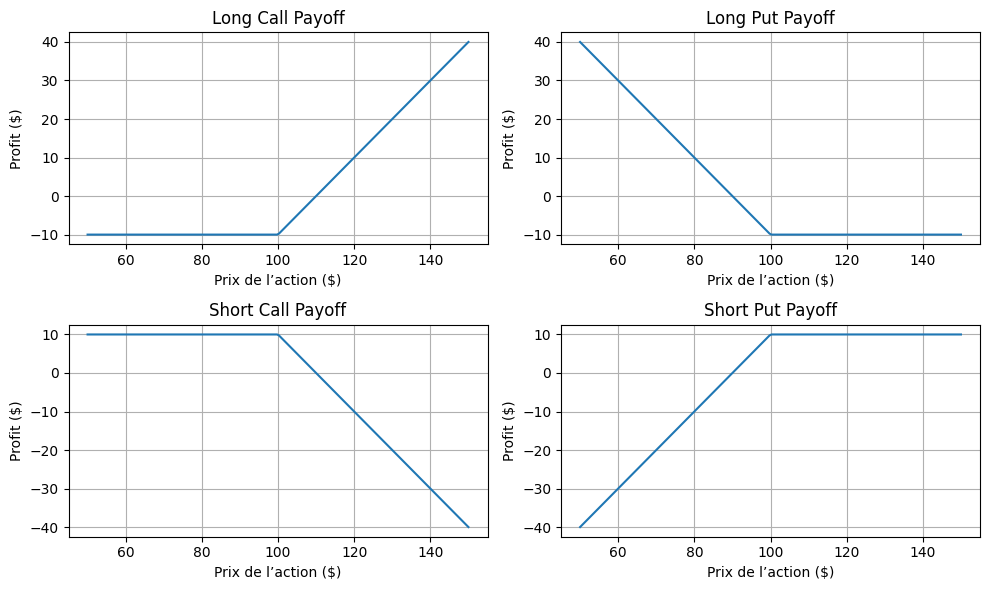

In [ ]:
def option_profit(S, K, premium, option_type, position):
  if option_type == 'call':
    profit = np.maximum(S - K, 0) - premium
  elif option_type == 'put':
    profit = np.maximum(K - S, 0) - premium  # Gain corrigé pour l'option put
  else:
    raise ValueError("Le type d’option doit être ‘call’ ou ‘put’.")
  return profit if position == 'long' else -profit

# Définition des paramètres
S = np.linspace(50, 150, 200) # fourchette de prix de l’action
K = 100 # Prix d'exercice (Strike)
premium = 10 # Prime de l'option

# Calculons la valeur du profit
long_call = option_profit(S, K,premium,'call', 'long')
short_call = option_profit(S, K, premium,'call', 'short')
long_put = option_profit(S, K, premium,'put', 'long')
short_put = option_profit(S, K, premium,'put', 'short')

#print(long_call)

# Tracer les résultats

fig, ax = plt.subplots(2, 2, figsize=(10, 6))

ax[0,0].plot(S, long_call)
ax[0,0].set_title('Long Call Payoff')
ax[0,0].set_xlabel('Prix de l’action ($)')
ax[0,0].set_ylabel('Profit ($)')
ax[0,0].grid()

ax[1,0].plot(S, short_call)
ax[1,0].set_title('Short Call Payoff')
ax[1,0].set_xlabel('Prix de l’action ($)')
ax[1,0].set_ylabel('Profit ($)')
ax[1,0].grid()

ax[0,1].plot(S, long_put)
ax[0,1].set_title('Long Put Payoff')
ax[0,1].set_xlabel('Prix de l’action ($)')
ax[0,1].set_ylabel('Profit ($)')
ax[0,1].grid()

ax[1,1].plot(S, short_put)
ax[1,1].set_title('Short Put Payoff')
ax[1,1].set_xlabel('Prix de l’action ($)')
ax[1,1].set_ylabel('Profit ($)')
ax[1,1].grid()

plt.tight_layout()
plt.show()

### II - Calcul des Call, Put et Greeks

**1. Prix actuel de l’action ($S_0$) : Delta ($\Delta$)**



* **Options d’achat (Call)** : Lorsque $S_0$ augmente, l’option d’achat devient plus précieuse. Cette relation est mesurée par le Delta, qui indique le taux de variation du prix de l’option par rapport aux variations du prix du sous-jacent. Pour les calls, $\Delta > 0$.


* **Options de vente (Put)** : Lorsque $S_0$ augmente, l’option de vente perd de la valeur. Pour les puts, $\Delta < 0$.


**2. Prix d’exercice ($K$) : Impact sur la valeur intrinsèque et sur le Delta**


* **Options d’achat (Call)** : Un prix d’exercice plus élevé réduit la valeur intrinsèque, ce qui diminue le prix du call. Le Delta des calls diminue lorsque l’option devient plus hors de la monnaie (out-of-the-money).

* **Options de vente (Put)** : Un prix d’exercice plus élevé augmente la valeur intrinsèque, ce qui accroît le prix du put. Le Delta des puts devient plus négatif lorsque l’option est davantage dans la monnaie (in-the-money).

**3. Durée avant l’échéance ($T$) : Thêta ($\Theta$) et Gamma ($\Gamma$)**


* **Thêta (Décroissance temporelle)** : Mesure la vitesse à laquelle le prix d’une option diminue avec le temps. Pour les calls et les puts, $\Theta < 0$ (les options perdent de la valeur à mesure que l’échéance approche), mais les options à long terme peuvent parfois augmenter en valeur en raison d’une valeur temps plus importante.


* **Gamma** : Mesure le taux de variation du Delta par rapport à $S_0$. Une durée plus longue avant l’échéance entraîne un Gamma plus élevé, ce qui signifie que le prix de l’option réagit plus fortement aux variations de $S_0$.

**4. Volatilité ($\sigma$) : Véga ($\nu$)**


* Véga mesure la sensibilité du prix de l’option aux variations de la volatilité.
Les prix des calls et des puts augmentent tous deux lorsque la volatilité s’accroît, car une volatilité plus élevée augmente la probabilité que l’option se termine dans la monnaie.

* Le Véga est maximal pour les options at-the-money et diminue lorsque l’option devient davantage in-the-money ou out-of-the-money.

**5. Taux d’intérêt sans risque ($r$) : Rhô ($\rho$)**

Options d’achat (Call) : $\rho_{\text{call}} > 0$. Une hausse du taux $r$ augmente la valeur des calls, car la valeur actuelle du prix d’exercice diminue.

Options de vente (Put) : $\rho_{\text{put}} < 0$. Une hausse du taux $r$ réduit la valeur des puts pour la même raison.

| Variable                     | Greek(s) associé(s) | Explication                                                                                                         |
| ---------------------------- | ------------------- | ------------------------------------------------------------------------------------------------------------------- |
| **Prix de l’action ($S_0$)** | $\Delta$, $\Gamma$  | $\Delta$ montre la sensibilité directe ; $\Gamma$ capture l’accélération du changement de prix.                     |
| **Prix d’exercice ($K$)**    | $\Delta$, $\Gamma$  | $K$ influence la valeur intrinsèque, affectant $\Delta$ et la courbure via $\Gamma$.                                |
| **Temps à l’échéance ($T$)** | $\Theta$, $\Gamma$  | $\Theta$ reflète la décroissance temporelle ; un $T$ plus long augmente $\Gamma$.                                   |
| **Volatilité ($\sigma$)**    | $\nu$ (Véga)        | Une volatilité plus élevée accroît la valeur des calls et des puts à cause de l’incertitude accrue.                 |
| **Taux sans risque ($r$)**   | $\rho$              | Le prix des calls augmente avec $\rho_{\text{call}} > 0$ ; celui des puts baisse avec $\rho_{\text{put}} < 0$.      |



### Formules des Greeks (Black-Scholes sans Dividendes)

| Greek | Formule (Call) | Formule (Put) |
| :--- | :--- | :--- |
| **Delta ($\Delta$)** | $N(d_1)$ | $N(d_1) - 1$ |
| **Gamma ($\Gamma$)** | $\frac{\phi(d_1)}{S\sigma \sqrt{T}}$ | $\frac{\phi(d_1)}{S\sigma \sqrt{T}}$ |
| **Véga ($\nu$)** | $\small S\phi(d_1) \sqrt{T}$ | $\small S\phi(d_1) \sqrt{T}$ |
| **Thêta ($\Theta$)** | $\small - \frac{S\phi(d_1)\sigma}{2\sqrt{T}} - r K e^{-rT}N(d_2)$ | $\small - \frac{S\phi(d_1)\sigma}{2\sqrt{T}} + r K e^{-rT}N(-d_2)$ |
| **Rhô ($\rho$)** | $\small KTe^{-rT}N(d_2)$ | $\small -KTe^{-rT}N(-d_2)$ |

**Fonction de Densité :**  
$\phi(x) = \frac{e^{-\frac{x^2}{2}}}{\sqrt{2\pi}}$

**Paramètres :**
* $d_1 = \frac{\ln(S/K) + (r + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}$
* $d_2 = d_1 - \sigma\sqrt{T}$

In [ ]:
# ==========================================
# 1. CALCUL DU TAUX SANS RISQUE (Excel)
# ==========================================

print("Chargement des données Excel...")
# Chargement du DataFrame et conversion en décimales (/ 100)
df_rf = pd.read_excel("DTB3.xlsx", sheet_name="Daily", index_col='observation_date') / 100

# Calcul de la moyenne pour obtenir le taux sans risque annuel
rf = df_rf['DTB3'].mean()
print(f"Taux sans risque calculé (rf) : {rf:.4f} ({rf*100:.2f}%)\n")

# ==========================================
# 2. MODÈLE BLACK-SCHOLES (Code Optimisé)
# ==========================================

class Option:
    def __init__(self, S, K, T, r, sigma):
        self.S = S
        self.K = K
        self.T = max(T, 1e-8)          # Protection contre la division par zéro (T=0)
        self.r = r
        self.sigma = max(sigma, 1e-8)  # Protection contre la division par zéro (sigma=0)

        # Calcul de d1 et d2 une seule fois
        self.d1 = (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma ** 2) * self.T) / (self.sigma * np.sqrt(self.T))
        self.d2 = self.d1 - self.sigma * np.sqrt(self.T)

    def price_call(self):
        return self.S * norm.cdf(self.d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(self.d2)

    def price_put(self):
        return self.K * np.exp(-self.r * self.T) * norm.cdf(-self.d2) - self.S * norm.cdf(-self.d1)

    def calculer_greeks(self, option_type):
        """Calcul des 5 Grecques selon les formules théoriques de l'image"""
        # Fonction de densité φ(d1)
        phi_d1 = norm.pdf(self.d1)

        # Facteur d'actualisation e^(-rT)
        exp_rt = np.exp(-self.r * self.T)

        # Formules communes (Gamma et Vega)
        gamma = phi_d1 / (self.S * self.sigma * np.sqrt(self.T))
        vega = self.S * phi_d1 * np.sqrt(self.T)

        # Premier terme commun pour le Theta
        theta_first_term = -(self.S * phi_d1 * self.sigma) / (2 * np.sqrt(self.T))

        if option_type == 'call':
            delta = norm.cdf(self.d1)
            theta = theta_first_term - self.r * self.K * exp_rt * norm.cdf(self.d2)
            rho = self.K * self.T * exp_rt * norm.cdf(self.d2)
        elif option_type == 'put':
            delta = norm.cdf(self.d1) - 1
            theta = theta_first_term + self.r * self.K * exp_rt * norm.cdf(-self.d2)
            rho = -self.K * self.T * exp_rt * norm.cdf(-self.d2)
        else:
            raise ValueError("Le type d'option doit être 'call' ou 'put'")

        return {"Delta": delta, "Gamma": gamma, "Vega": vega, "Theta": theta, "Rho": rho}


def put_from_parity(S, K, T, r, call_price):
    """ Prix du Put = Prix du Call - Prix de l'action + Valeur actuelle du strike """
    return call_price - S + K * np.exp(-r * T)


def call_from_parity(S, K, T, r, put_price):
    """ Prix du Call = Prix du Put + Prix de l'action - Valeur actuelle du strike """
    return put_price + S - K * np.exp(-r * T)


def evaluer_scenario(nom, S, K, T, r, sigma):
    """ Fonction regroupant l'analyse complète pour éviter de répéter le code """
    print(f"--- {nom} : S={S}, K={K} ---")

    # On instancie l'option UNE SEULE FOIS
    opt = Option(S, K, T, r, sigma)
    prix_call = opt.price_call()
    prix_put = opt.price_put()

    # Détermination du statut ITM/OTM/ATM
    statut_call = 'ITM' if S > K else ('OTM' if S < K else 'ATM')
    statut_put = 'ITM' if S < K else ('OTM' if S > K else 'ATM')

    # Affichage des prix Black-Scholes
    print(f"Le prix du Call ({statut_call}) est de : {prix_call:.4f}")
    print(f"Le prix du Put ({statut_put}) est de : {prix_put:.4f}")

    # Vérification par la parité
    put_parite = put_from_parity(S, K, T, r, prix_call)
    call_parite = call_from_parity(S, K, T, r, prix_put)

    print(f"Le prix du Put calculé par parité est de  : {put_parite:.4f}")
    print(f"Le prix du Call calculé par parité est de : {call_parite:.4f}")

    # Calcul et affichage des Grecques
    greeks_call = opt.calculer_greeks('call')
    greeks_put = opt.calculer_greeks('put')

    print("\nGrecques du Call :", " | ".join([f"{k}: {v:.4f}" for k, v in greeks_call.items()]))
    print("Grecques du Put  :", " | ".join([f"{k}: {v:.4f}" for k, v in greeks_put.items()]))
    print("\n")

# ==========================================
# 3. EXÉCUTION DES SCÉNARIOS
# ==========================================

# Paramètres communs
T = 0.5       # Maturité (6 mois)
sigma = 0.3   # Volatilité
# Le taux 'r' utilisé ci-dessous est désormais 'rf' (calculé dynamiquement plus haut)
T_1 = 2
sigma_1 = 0


# Lancement des scénarios
evaluer_scenario("Scénario 1", S=50, K=100, T=T, r=rf, sigma=sigma)
evaluer_scenario("Scénario 2", S=100, K=50, T=T, r=rf, sigma=sigma)

evaluer_scenario("Scénario 3 (T=0.5, r=2%)",  S=50, K=100, T=0.5, r=0.02, sigma=0.2)
evaluer_scenario("Scénario 4 (T=0.5, r=5%)",  S=100, K=50, T=0.5, r=0.05, sigma=0.2)
evaluer_scenario("Scénario 5 (T=0.5, r=10%)", S=100, K=100, T=1.0, r=0.10, sigma=0.2)

Chargement des données Excel...
Taux sans risque calculé (rf) : 0.0224 (2.24%)

--- Scénario 1 : S=50, K=100 ---
Le prix du Call (OTM) est de : 0.0026
Le prix du Put (ITM) est de : 48.8893
Le prix du Put calculé par parité est de  : 48.8893
Le prix du Call calculé par parité est de : 0.0026

Grecques du Call : Delta: 0.0009 | Gamma: 0.0003 | Vega: 0.1124 | Theta: -0.0347 | Rho: 0.0222
Grecques du Put  : Delta: -0.9991 | Gamma: 0.0003 | Vega: 0.1124 | Theta: 2.1795 | Rho: -49.4211


--- Scénario 2 : S=100, K=50 ---
Le prix du Call (ITM) est de : 50.5584
Le prix du Put (OTM) est de : 0.0017
Le prix du Put calculé par parité est de  : 0.0017
Le prix du Call calculé par parité est de : 50.5584

Grecques du Call : Delta: 0.9997 | Gamma: 0.0001 | Vega: 0.0796 | Theta: -1.1303 | Rho: 24.7055
Grecques du Put  : Delta: -0.0003 | Gamma: 0.0001 | Vega: 0.0796 | Theta: -0.0232 | Rho: -0.0162


--- Scénario 3 (T=0.5, r=2%) : S=50, K=100 ---
Le prix du Call (OTM) est de : 0.0000
Le prix du Put (ITM)

### III - Simulation Monte Carlo du prix d'un Call et d'un Put

La méthode de Monte Carlo est une technique de simulation qui utilise l'échantillonnage aléatoire pour obtenir des résultats numériques. Dans le contexte de la valorisation des options, elle est utilisée pour simuler de multiples trajectoires futures du prix de l'actif sous-jacent et ensuite calculer la moyenne des payoffs actualisés.

Le processus se déroule comme suit :

1.  **Simulation du prix de l'actif à l'échéance ($S_T$)** :
    Nous modélisons le prix de l'actif sous-jacent ($S$) à l'échéance ($T$) en utilisant le mouvement brownien géométrique, une hypothèse courante pour les prix d'actifs. La formule pour simuler $S_T$ est la suivante :

    $$S_T = S_0 \times e^{(r - \frac{1}{2}\sigma^2)T + \sigma\sqrt{T}Z}$$

    Où :
    *   $S_0$ est le prix actuel de l'actif.
    *   $r$ est le taux d'intérêt sans risque.
    *   $\sigma$ est la volatilité de l'actif.
    *   $T$ est le temps restant jusqu'à l'échéance (en années).
    *   $Z$ est une variable aléatoire suivant une distribution normale standard (moyenne 0, écart-type 1).

2.  **Calcul du Payoff de l'option à l'échéance** :
    Pour chaque simulation de $S_T$, nous calculons le payoff de l'option à l'échéance :

    *   Pour une **option Call** :
        $$Payoff_{Call} = \max(S_T - K, 0)$$
    *   Pour une **option Put** :
        $$Payoff_{Put} = \max(K - S_T, 0)$$

    Où $K$ est le prix d'exercice (strike).

3.  **Actualisation des Payoffs et Calcul de la Moyenne** :
    Après avoir exécuté un grand nombre de simulations (itérations), nous obtenons une série de payoffs. Nous actualisons ensuite la moyenne de ces payoffs au temps présent pour obtenir le prix de l'option :

    $$Prix_{Option} = e^{-rT} \times \frac{1}{N} \sum_{i=1}^{N} Payoff_i$$

    Où $N$ est le nombre total de simulations.

Cette méthode permet d'estimer le prix des options, surtout lorsque les modèles analytiques (comme Black-Scholes) sont difficiles à appliquer (par exemple, pour des options avec des trajectoires de prix complexes ou des payoffs non standards).

In [ ]:
# ==========================================
# 1. MODÈLE DE MONTE-CARLO OPTIMISÉ + GRECQUES
# ==========================================
class Option_Pricing_Optimized:
    def __init__(self, S, K, T, r, sigma, iterations):
        self.S = S
        self.K = K
        self.T = max(T, 1e-8)          # Protection contre la division par zéro (T=0)
        self.r = r
        self.sigma = max(sigma, 1e-8)  # Protection contre la division par zéro (sigma=0)
        self.iterations = iterations

    def price_options(self):
        """ Calcul des prix par simulation de Monte-Carlo vectorisée """
        rand = np.random.normal(0, 1, self.iterations)
        stock_prices = self.S * np.exp((self.r - 0.5 * self.sigma**2) * self.T
                                       + self.sigma * np.sqrt(self.T) * rand)

        # Calcul des Payoffs
        payoff_call = np.maximum(stock_prices - self.K, 0)
        payoff_put = np.maximum(self.K - stock_prices, 0)

        # Actualisation
        discount_factor = np.exp(-self.r * self.T)

        return {
            "Call": discount_factor * np.mean(payoff_call),
            "Put": discount_factor * np.mean(payoff_put)
        }

    def calculer_greeks(self, option_type):
        """ Calcul analytique des 5 Grecques (Modèle Black-Scholes) """
        d1 = (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma ** 2) * self.T) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)

        phi_d1 = norm.pdf(d1)
        exp_rt = np.exp(-self.r * self.T)

        # Formules communes (Gamma et Vega)
        gamma = phi_d1 / (self.S * self.sigma * np.sqrt(self.T))
        vega = (self.S * phi_d1 * np.sqrt(self.T)) / 100  # Mise à l'échelle pour 1%

        theta_first_term = -(self.S * phi_d1 * self.sigma) / (2 * np.sqrt(self.T))

        if option_type == 'call':
            delta = norm.cdf(d1)
            theta = (theta_first_term - self.r * self.K * exp_rt * norm.cdf(d2)) / 365
            rho = (self.K * self.T * exp_rt * norm.cdf(d2)) / 100
        elif option_type == 'put':
            delta = norm.cdf(d1) - 1
            theta = (theta_first_term + self.r * self.K * exp_rt * norm.cdf(-d2)) / 365
            rho = (-self.K * self.T * exp_rt * norm.cdf(-d2)) / 100

        return {"Delta": delta, "Gamma": gamma, "Vega": vega, "Theta": theta, "Rho": rho}

# ==========================================
# 2. CRÉATION DES SCÉNARIOS
# ==========================================
scenarios_config = [
    # Scénarios utilisant le taux calculé depuis Excel (rf)
    {"S": 100, "K": 50, "T": 1.0, "sigma": 0.3, "r": rf},
    {"S": 100, "K": 50, "T": 1.0, "sigma": 0.4, "r": rf},
    {"S": 100, "K": 50, "T": 1.0, "sigma": 0.5, "r": rf},
    {"S": 50,  "K": 100,"T": 1.0, "sigma": 0.6, "r": rf},
    # Scénarios utilisant des taux manuels pour comparer l'impact (ex: Rho)
    {"S": 100, "K": 50, "T": 1.0, "sigma": 0.3, "r": 0.04},
    {"S": 100, "K": 50, "T": 1.0, "sigma": 0.3, "r": 0.08},
    {"S": 100, "K": 50, "T": 1.0, "sigma": 0.3, "r": 0.12},
    {"S": 100,  "K": 50, "T": 1.0, "sigma": 0.3, "r": 0.15}
]

iterations = 10000000 # 10 million d'itérations par scénario
resultats = []

print(f"Calcul des {len(scenarios_config)} scénarios en cours ({iterations:,} itérations chacun)...")

for i, sc in enumerate(scenarios_config):

    np.random.seed(42) # même seed pour réduire le bruit de Monte-Carlo et garantir la reproductibilité des résultats entre les scénarios

    # Instanciation avec le "r" lu directement depuis le dictionnaire du scénario
    model = Option_Pricing_Optimized(sc["S"], sc["K"], sc["T"], sc["r"], sc["sigma"], iterations)

    # Récupération des prix
    prix = model.price_options()

    # Récupération des Grecques
    greeks_call = model.calculer_greeks('call')
    greeks_put = model.calculer_greeks('put')

    # Ajout au tableau de bord
    resultats.append({
        "Scénario": f"Scén {i+1}",
        "S": sc["S"],
        "K": sc["K"],
        "T": sc["T"],
        "r": sc["r"],
        "Sigma": sc["sigma"],
        "Prix Call": prix["Call"],
        "Prix Put": prix["Put"],
        "Δ Call": greeks_call["Delta"],
        "Δ Put": greeks_put["Delta"],
        "Γ Gamma": greeks_call["Gamma"],
        "ν Vega": greeks_call["Vega"],
        "Θ Call": greeks_call["Theta"],
        "Θ Put": greeks_put["Theta"],
        "ρ Call": greeks_call["Rho"],
        "ρ Put": greeks_put["Rho"]
    })

# ==========================================
# 3. DATAFRAME ET AFFICHAGE VISUEL
# ==========================================
# Création du Dataframe principal
df_final = pd.DataFrame(resultats)

# Copie pour l'affichage avec des arrondis propres
df_display = df_final.copy()

# Arrondi des prix à 2 décimales
df_display['Prix Call'] = df_display['Prix Call'].round(2)
df_display['Prix Put'] = df_display['Prix Put'].round(2)

# Arrondi du taux 'r' à 4 décimales pour plus de lisibilité
df_display['r'] = df_display['r'].round(4)

# Arrondi des Grecques à 4 décimales
colonnes_grecques = ["Δ Call", "Δ Put", "Γ Gamma", "ν Vega", "Θ Call", "Θ Put", "ρ Call", "ρ Put"]
for col in colonnes_grecques:
    df_display[col] = df_display[col].round(4)

print("\n--- Tableau Récapitulatif avec Grecques ---")
# Affichage HTML propre si exécuté dans Colab / Jupyter
try:
    display(df_display)
except NameError:
    print(df_display.to_string(index=False))

Calcul des 8 scénarios en cours (10,000,000 itérations chacun)...

--- Tableau Récapitulatif avec Grecques ---


,Scénario,S,K,T,r,Sigma,Prix Call,Prix Put,Δ Call,Δ Put,Γ Gamma,ν Vega,Θ Call,Θ Put,ρ Call,ρ Put
0,Scén 1,100,50,1.0,0.0224,0.3,51.16,0.06,0.9944,-0.0056,0.0005,0.0160,-0.0036,-0.0006,0.4827,-0.0062
1,Scén 2,100,50,1.0,0.0224,0.4,51.51,0.40,0.9766,-0.0234,0.0014,0.0552,-0.0059,-0.0029,0.4615,-0.0274
2,Scén 3,100,50,1.0,0.0224,0.5,52.27,1.17,0.9536,-0.0464,0.0019,0.0971,-0.0093,-0.0063,0.4309,-0.0581
3,Scén 4,50,100,1.0,0.0224,0.6,2.70,50.48,0.2067,-0.7933,0.0095,0.1428,-0.0122,-0.0062,0.0764,-0.9015
4,Scén 5,100,50,1.0,0.0400,0.3,52.01,0.05,0.9953,-0.0047,0.0005,0.0138,-0.0058,-0.0005,0.4752,-0.0052
5,Scén 6,100,50,1.0,0.0800,0.3,53.87,0.03,0.9968,-0.0032,0.0003,0.0097,-0.0104,-0.0003,0.4580,-0.0035
6,Scén 7,100,50,1.0,0.1200,0.3,55.67,0.02,0.9979,-0.0021,0.0002,0.0067,-0.0148,-0.0002,0.4411,-0.0023
7,Scén 8,100,50,1.0,0.1500,0.3,56.98,0.01,0.9985,-0.0015,0.0002,0.0050,-0.0178,-0.0001,0.4287,-0.0017


Comme on le voit dans le tableau ci-dessus, les paramètres T, Sigma on un impact sur le prix du Call et du Put.

## Graphics greeks

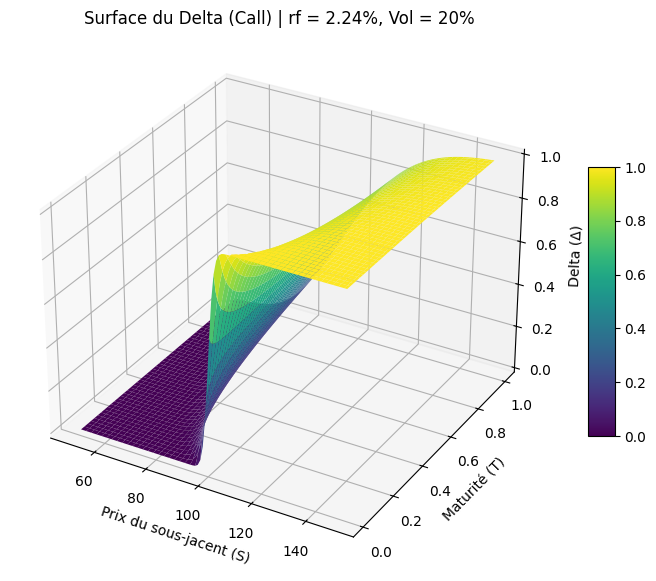

In [ ]:
# ==========================================
# 1. CALCUL DU DELTA et visualisation 3D
# ==========================================

def calculate_d1(S, K, T, rf, Sigma):
    return (np.log(S / K) + (rf + 0.5 * Sigma ** 2) * T) / (Sigma * np.sqrt(T))

def delta(S, K, T, rf, Sigma):
    d1 = calculate_d1(S, K, T, rf, Sigma)
    return norm.cdf(d1)

# Paramètres
K = 100
Sigma = 0.2
# Assure-toi que rf est défini
# Exemple :
# rf = 0.03

# Grille
S = np.linspace(50, 150, 100)
T = np.linspace(0.01, 1, 100)
S, T = np.meshgrid(S, T)

# Calcul
Delta = delta(S, K, T, rf, Sigma)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface
surf = ax.plot_surface(S, T, Delta, cmap='viridis')

# Labels
ax.set_title(f"Surface du Delta (Call) | rf = {rf*100:.2f}%, Vol = {Sigma*100:.0f}%")
ax.set_xlabel("Prix du sous-jacent (S)")
ax.set_ylabel("Maturité (T)")
ax.set_zlabel("Delta (Δ)")

# Colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

# Affichage
plt.show()

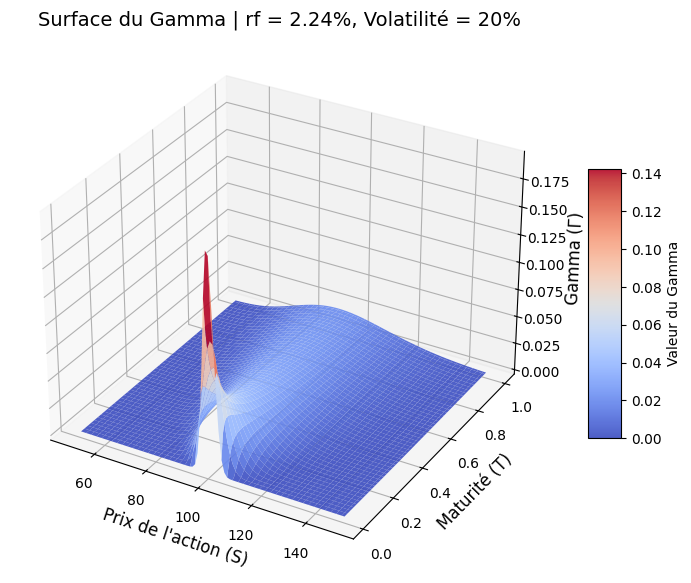

In [ ]:
# ==========================================
# 3. CALCUL ET VISUALISATION 3D DU GAMMA
# ==========================================

# Calcul du Gamma (sans q, avec rf)
def gamma(S, K, T, rf, Sigma):
    d1 = calculate_d1(S, K, T, rf, Sigma)
    # Sans dividende, la formule se simplifie
    return norm.pdf(d1) / (S * Sigma * np.sqrt(T))

# Paramètres
K = 100         # Prix d'exercice (Strike)
Sigma = 0.2     # Volatilité (20%)

# Génération des données pour l'axe X (Prix) et l'axe Y (Maturité)
S = np.linspace(50, 150, 100)
T = np.linspace(0.01, 1, 100)  # Évite la division par zéro si T=0
S, T = np.meshgrid(S, T)

# Calcul du Gamma
Gamma = gamma(S, K, T, rf, Sigma)

# --- Graphique 3D avec Matplotlib ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Tracer la surface
surf = ax.plot_surface(S, T, Gamma, cmap='coolwarm', edgecolor='none', alpha=0.9)

# Titres et labels
ax.set_title(f"Surface du Gamma | rf = {rf*100:.2f}%, Volatilité = {Sigma*100:.0f}%", fontsize=14)
ax.set_xlabel("Prix de l'action (S)", fontsize=12)
ax.set_ylabel("Maturité (T)", fontsize=12)
ax.set_zlabel("Gamma (Γ)", fontsize=12)

# Barre de couleur
fig.colorbar(surf, shrink=0.5, aspect=8, label='Valeur du Gamma')

# Affichage
plt.show()

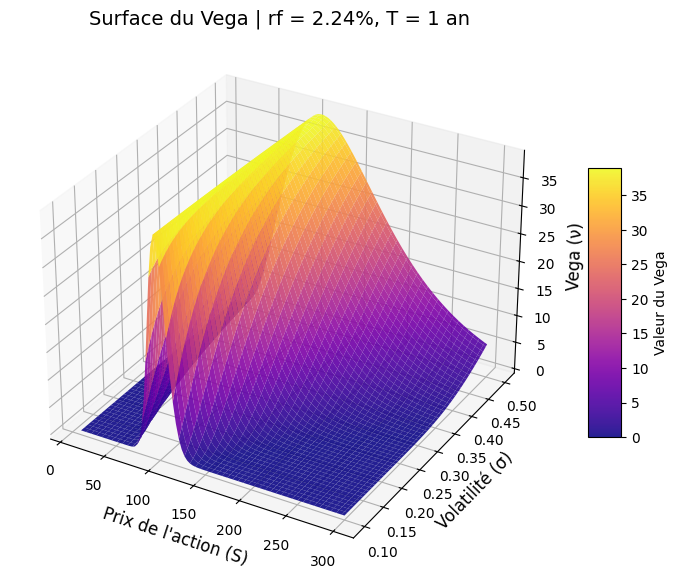

In [ ]:
# ==========================================
# 4. CALCUL ET VISUALISATION 3D DU VEGA
# ==========================================

# Calcul du Vega (sans q, avec rf)
def vega(S, K, T, rf, Sigma):
    d1 = calculate_d1(S, K, T, rf, Sigma)
    # Sans dividende, le terme np.exp(-q * T) disparaît
    return S * np.sqrt(T) * norm.pdf(d1)

# Paramètres
K = 100         # Prix d'exercice (Strike)
T_fixed = 1     # Maturité fixée à 1 an

# Génération des données pour l'axe X (Prix) et l'axe Y (Volatilité)
S = np.linspace(10, 300, 100)            # Prix de l'action de 10 à 300
Volatility = np.linspace(0.1, 0.5, 100)  # Volatilité de 10% à 50%
S, Volatility = np.meshgrid(S, Volatility)

# Calcul du Vega
Vega = vega(S, K, T_fixed, rf, Volatility)

# --- Graphique 3D avec Matplotlib ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Tracer la surface (edgecolor='none' pour un rendu plus lisse)
surf = ax.plot_surface(S, Volatility, Vega, cmap='plasma', edgecolor='none', alpha=0.9)

# Titres et labels
ax.set_title(f"Surface du Vega | rf = {rf*100:.2f}%, T = {T_fixed} an", fontsize=14)
ax.set_xlabel("Prix de l'action (S)", fontsize=12)
ax.set_ylabel("Volatilité (σ)", fontsize=12)
ax.set_zlabel("Vega (ν)", fontsize=12)

# Barre de couleur
fig.colorbar(surf, shrink=0.5, aspect=8, label='Valeur du Vega')

# Affichage
plt.show()

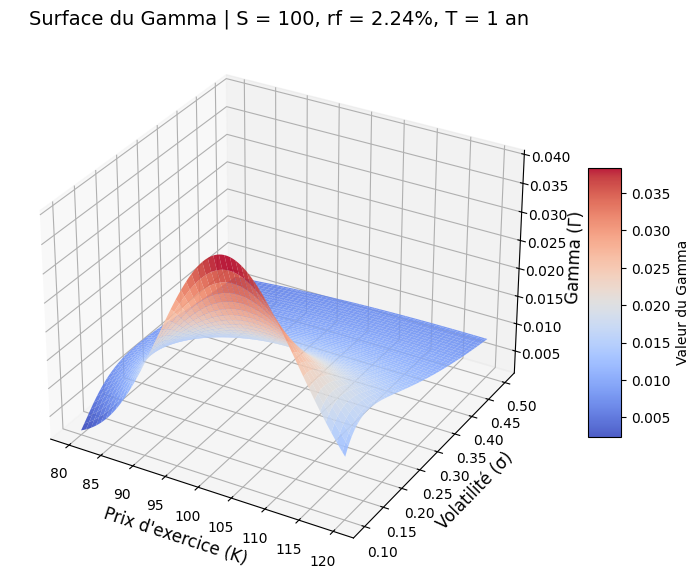

In [ ]:
# ==========================================
# 5. CALCUL ET VISUALISATION 3D DU GAMMA (K vs Volatilité)
# ==========================================

# Calcul du Gamma (sans q, avec rf)
def gamma(S, K, T, rf, Sigma):
    d1 = calculate_d1(S, K, T, rf, Sigma)
    # Sans dividende, le terme np.exp(-q*T) disparaît
    return norm.pdf(d1) / (S * Sigma * np.sqrt(T))

# Paramètres
S_fixed = 100    # Prix du sous-jacent fixé
T_fixed = 1      # Maturité fixée à 1 an

# Génération des données pour l'axe X (Strike) et l'axe Y (Volatilité)
K = np.linspace(80, 120, 100)        # Prix d'exercice (Strike) de 80 à 120
Sigma = np.linspace(0.1, 0.5, 100)   # Volatilité de 10% à 50%
K, Sigma = np.meshgrid(K, Sigma)

# Calcul du Gamma
Gamma = gamma(S_fixed, K, T_fixed, rf, Sigma)

# --- Graphique 3D avec Matplotlib ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Tracer la surface (edgecolor='none' pour un rendu plus net)
surf = ax.plot_surface(K, Sigma, Gamma, cmap='coolwarm', edgecolor='none', alpha=0.9)

# Titres et labels
ax.set_title(f"Surface du Gamma | S = {S_fixed}, rf = {rf*100:.2f}%, T = {T_fixed} an", fontsize=14)
ax.set_xlabel("Prix d'exercice (K)", fontsize=12)
ax.set_ylabel("Volatilité (σ)", fontsize=12)
ax.set_zlabel("Gamma (Γ)", fontsize=12)

# Barre de couleur
fig.colorbar(surf, shrink=0.5, aspect=8, label='Valeur du Gamma')

# Affichage
plt.show()

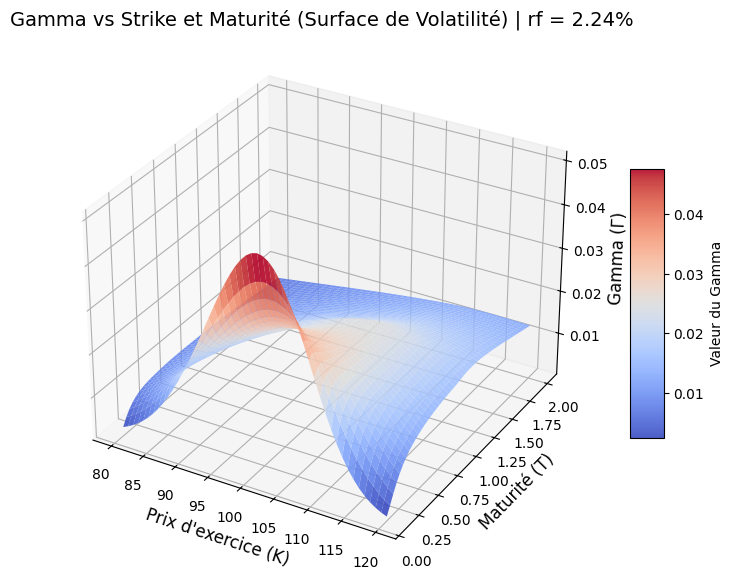

In [ ]:
# ==========================================
# 6. SURFACE DE VOLATILITÉ & INTERPOLATION
# ==========================================
# Données de la surface de volatilité
strikes = np.array([80, 90, 100, 110, 120])  # 5 prix d'exercice
maturities = np.array([0.1, 0.5, 1.0, 2.0])  # 4 maturités
vol_surface = np.array([  # Matrice 4x5 des volatilités implicites
    [0.30, 0.28, 0.25, 0.22, 0.20],
    [0.25, 0.23, 0.20, 0.18, 0.17],
    [0.22, 0.20, 0.18, 0.15, 0.14],
    [0.28, 0.26, 0.24, 0.22, 0.21],
])

# Interpolation de la surface de volatilité
vol_interp = RegularGridInterpolator((maturities, strikes), vol_surface)

# Calcul du Gamma (sans q, avec rf)
def gamma(S, K, T, rf, Sigma):
    d1 = calculate_d1(S, K, T, rf, Sigma)
    # Sans dividende, le terme np.exp(-q * T) disparaît
    return norm.pdf(d1) / (S * Sigma * np.sqrt(T))

# Paramètres
S_fixed = 100  # Prix du sous-jacent fixé
# rf est défini dynamiquement au-dessus

# Génération des données pour Strike (K) et Maturité (T)
K = np.linspace(80, 120, 50)   # Prix d'exercice
T = np.linspace(0.1, 2.0, 50)  # Temps à l'échéance
K, T = np.meshgrid(K, T)

# Calcul du Gamma avec Volatilité Non Constante
Gamma = np.zeros_like(K)
for i in range(K.shape[0]):
    for j in range(K.shape[1]):
        # Interpolation de la volatilité pour chaque paire (T, K)
        Sigma = vol_interp((T[i, j], K[i, j]))
        Gamma[i, j] = gamma(S_fixed, K[i, j], T[i, j], rf, Sigma)

# --- Graphique 3D avec Matplotlib ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Tracer la surface (edgecolor='none' pour un rendu plus net)
surf = ax.plot_surface(K, T, Gamma, cmap='coolwarm', edgecolor='none', alpha=0.9)

# Titres et labels
ax.set_title(f"Gamma vs Strike et Maturité (Surface de Volatilité) | rf = {rf*100:.2f}%", fontsize=14)
ax.set_xlabel("Prix d'exercice (K)", fontsize=12)
ax.set_ylabel("Maturité (T)", fontsize=12)
ax.set_zlabel("Gamma (Γ)", fontsize=12)

# Barre de couleur
fig.colorbar(surf, shrink=0.5, aspect=8, label='Valeur du Gamma')

# Affichage
plt.show()

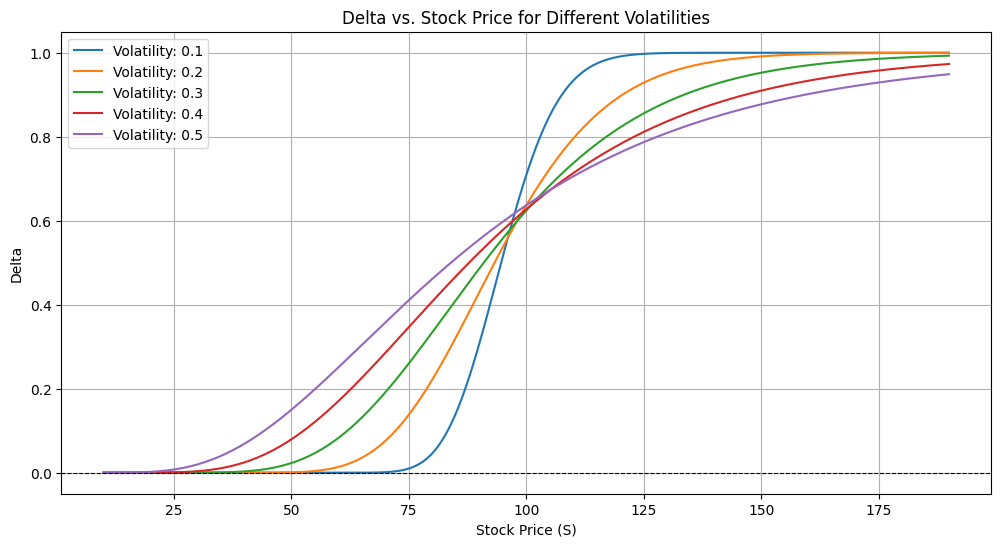

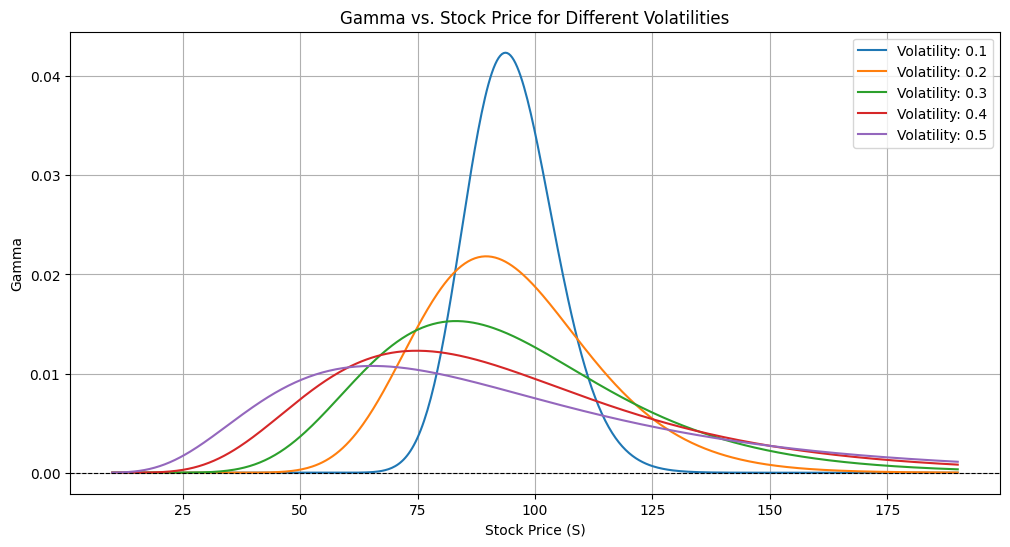

In [ ]:
# Helper functions for d1 and d2
def calculate_d1_d2(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

# Greeks
def delta(S, K, T, r, sigma, option_type='call'):
    d1, _ = calculate_d1_d2(S, K, T, r, sigma)
    if option_type == 'call':
        return norm.cdf(d1)
    elif option_type == 'put':
        return -norm.cdf(-d1)

def gamma(S, K, T, r, sigma):
    d1, _ = calculate_d1_d2(S, K, T, r, sigma)
    return ( norm.pdf(d1)) / (S * sigma * np.sqrt(T))

# Parameters
S = np.linspace(10, 190, 500)  # Stock prices
K = 100                       # Strike price
T = 1.0                       # Time to maturity
r = 0.05                      # Risk-free rate
volatilities = [0.1, 0.2, 0.3, 0.4, 0.5]  # Different levels of volatility

# Plot Delta for different volatilities
plt.figure(figsize=(12, 6))
for sigma in volatilities:
    delta_call = delta(S, K, T, r, sigma, option_type='call')
    plt.plot(S, delta_call, label=f"Volatility: {sigma}")
plt.title("Delta vs. Stock Price for Different Volatilities")
plt.xlabel("Stock Price (S)")
plt.ylabel("Delta")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend()
plt.grid()
plt.show()

# Plot Gamma for different volatilities
plt.figure(figsize=(12, 6))
for sigma in volatilities:
    gamma_values = gamma(S, K, T, r, sigma)
    plt.plot(S, gamma_values, label=f"Volatility: {sigma}")
plt.title("Gamma vs. Stock Price for Different Volatilities")
plt.xlabel("Stock Price (S)")
plt.ylabel("Gamma")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend()
plt.grid()
plt.show()


---
Les Grecs constituent un ensemble d'indicateurs de sensibilité indispensables à la gestion des options, chacun capturant une dimension distincte du risque. Le Delta mesure la sensibilité du prix de l'option aux variations du sous-jacent et révèle un comportement particulièrement instructif : à faible volatilité, la transition entre 0 et 1 est quasi-binaire autour du strike, tandis qu'à forte volatilité elle s'étale progressivement, traduisant l'incertitude accrue sur le prix final. Le Gamma, dérivée seconde du prix par rapport au sous-jacent et donc dérivée du Delta, est sans doute le Greek le plus critique en pratique, ses surfaces 3D montrent un pic très concentré autour du strike pour les options proches de l'échéance à faible volatilité, illustrant le risque de "gamma explosion" particulièrement dangereux pour un vendeur d'options en fin de vie. Le Vega, identique pour un call et un put de mêmes paramètres en vertu de la parité call-put, atteint son maximum pour les options ATM et s'annule aux extrêmes, ce qui fait d'un straddle ATM un pari pur sur la volatilité implicite sans exposition directionnelle. Le Theta, toujours de signe opposé au Gamma, formalise le trade-off fondamental de la gestion d'options : être long Gamma et donc bénéficier des grands mouvements de marché se paie par une érosion quotidienne de la valeur temps, relation capturée par l'équation de Black-Scholes elle-même. Enfin, le Rho reste marginal pour des options court terme mais devient significatif sur des maturités longues, reflétant l'impact du taux sans risque sur la valeur actuelle du strike. Pris ensemble, ces cinq Grecs ne sont pas indépendants : ils sont liés par la structure mathématique de Black-Scholes, ce que la vérification numérique par la parité call-put confirme à chaque scénario.

---

# IV - Barrier Options

           Comparaison : Call Vanilla vs Options Barrières            
S=100, K=100, T=1.0, r=0.05, σ=0.2

📌 Call Vanilla (Black-Scholes) : 10.4506



,Barrière H,Type,Prix MC,Std Error,Prix Analytique,Écart vs Vanilla (%)
0,80,down-out,10.3683,0.0208,10.3513,-0.79
1,80,down-in,0.0622,0.0013,N/A,-99.40
2,80,up-out,0.0000,0.0000,N/A,-100.00
3,80,up-in,10.4305,0.0208,N/A,-0.19
4,99,down-out,3.4921,0.0154,1.3675,-66.59
5,99,down-in,6.9385,0.0170,N/A,-33.61
6,99,up-out,0.0000,0.0000,N/A,-100.00
7,99,up-in,10.4305,0.0208,N/A,-0.19
8,110,down-out,0.0015,0.0003,N/A,-99.99
9,110,down-in,10.4290,0.0208,N/A,-0.21


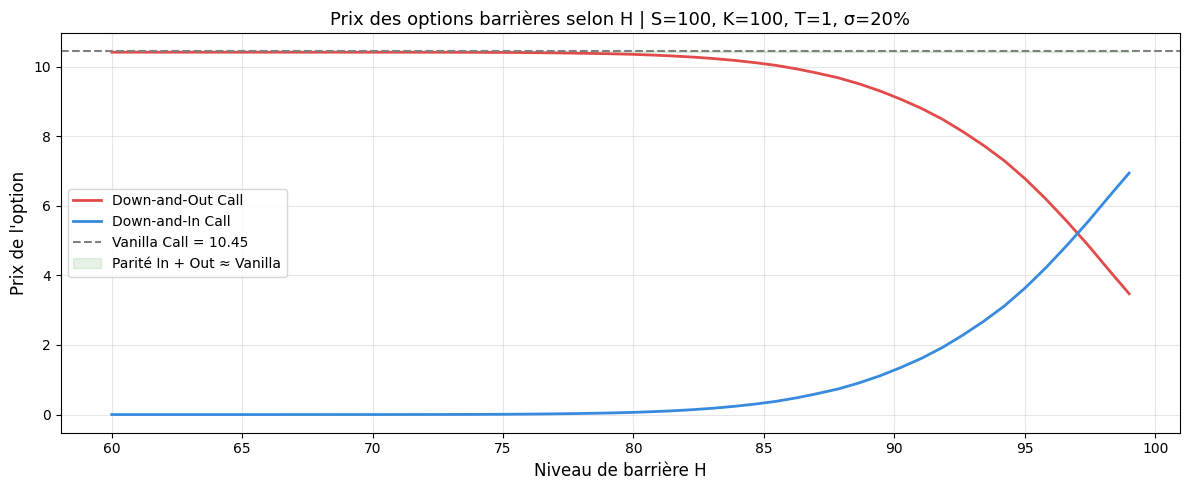


✅ Propriété clé : Down-and-Out + Down-and-In = Call Vanilla
   Vérification à H=80 : 10.4166 + 0.0000 ≈ 10.4506


In [ ]:
# ============================================================
# OPTIONS BARRIÈRES — Pricing Monte Carlo + Formule analytique
# ============================================================

# ────────────────────────────────────────────────────────────
# 1. Pricing Monte Carlo (Down-and-Out Call)
# ────────────────────────────────────────────────────────────
def barrier_option_monte_carlo(S, K, H, T, r, sigma, option_type='call',
                                barrier_type='down-out', n_sim=100_000, n_steps=50):
    """
    Pricing d'une option barrière par Monte Carlo avec trajectoires complètes.

    Paramètres :
    - S           : Prix spot
    - K           : Strike
    - H           : Niveau de barrière
    - T           : Maturité (en années)
    - r           : Taux sans risque
    - sigma       : Volatilité
    - option_type : 'call' ou 'put'
    - barrier_type: 'down-out', 'down-in', 'up-out', 'up-in'
    - n_sim       : Nombre de simulations
    - n_steps     : Nombre de pas de temps (252 = jours de trading)
    """
    np.random.seed(42)
    dt = T / n_steps

    # Simulation des trajectoires complètes (GBM)
    Z = np.random.normal(0, 1, (n_sim, n_steps))
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(increments, axis=1)
    paths = S * np.exp(log_paths)  # Shape : (n_sim, n_steps)

    S_T = paths[:, -1]  # Prix final

    # Détection du franchissement de barrière
    if 'down' in barrier_type:
        barrier_hit = np.any(paths <= H, axis=1)  # Touche la barrière par le bas
    else:  # 'up'
        barrier_hit = np.any(paths >= H, axis=1)  # Touche la barrière par le haut

    # Payoff brut
    if option_type == 'call':
        payoff = np.maximum(S_T - K, 0)
    else:
        payoff = np.maximum(K - S_T, 0)

    # Application de la condition barrière
    if 'out' in barrier_type:
        payoff = np.where(barrier_hit, 0, payoff)   # Knock-out : annulé si touché
    else:  # 'in'
        payoff = np.where(barrier_hit, payoff, 0)   # Knock-in  : actif si touché

    price = np.exp(-r * T) * np.mean(payoff)
    std_error = np.exp(-r * T) * np.std(payoff) / np.sqrt(n_sim)

    return price, std_error
    print(f"Barrier Option - Monte-Carlo Pricing  => Prix : {price:.4f} | Std Error : {se:.4f}")

# ────────────────────────────────────────────────────────────
# 2. Formule analytique — Down-and-Out Call (Merton 1973)
# ────────────────────────────────────────────────────────────
def down_and_out_call_analytical(S, K, H, T, r, sigma):
    """
    Formule fermée pour un Down-and-Out Call (H < K).
    Valide uniquement si H <= K.
    """
    if H >= K:
        raise ValueError("Pour la formule analytique Down-and-Out Call, H doit être < K")

    lam = (r + 0.5 * sigma**2) / (sigma**2)
    x1  = np.log(S / H) / (sigma * np.sqrt(T)) + lam * sigma * np.sqrt(T)
    y1  = np.log(H**2 / (S * K)) / (sigma * np.sqrt(T)) + lam * sigma * np.sqrt(T)

    d1  = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2  = d1 - sigma * np.sqrt(T)

    vanilla_call = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

    barrier_adj  = (S * (H / S)**(2 * lam) * norm.cdf(y1)
                  - K * np.exp(-r * T) * (H / S)**(2 * lam - 2) * norm.cdf(y1 - sigma * np.sqrt(T)))

    return vanilla_call - barrier_adj


# ────────────────────────────────────────────────────────────
# 3. Exécution et comparaison
# ────────────────────────────────────────────────────────────
S, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.2

barriers = [80, 99, 110]  # Différents niveaux de barrière
barrier_types = ['down-out', 'down-in', 'up-out', 'up-in']

print("=" * 70)
print(f"{'Comparaison : Call Vanilla vs Options Barrières':^70}")
print(f"S={S}, K={K}, T={T}, r={r}, σ={sigma}")
print("=" * 70)

# Call vanilla de référence
opt = Option(S, K, T, r, sigma)
vanilla_price = opt.price_call()
print(f"\n📌 Call Vanilla (Black-Scholes) : {vanilla_price:.4f}\n")

results = []
for H in barriers:
    for bt in barrier_types:
        price_mc, se = barrier_option_monte_carlo(S, K, H, T, r, sigma,
                                                   barrier_type=bt, n_sim=500_000)
        # Formule analytique uniquement pour down-out call avec H < K
        price_analytical = None
        if bt == 'down-out' and H < K:
            try:
                price_analytical = down_and_out_call_analytical(S, K, H, T, r, sigma)
            except Exception:
                pass

        results.append({
            'Barrière H': H,
            'Type': bt,
            'Prix MC': round(price_mc, 4),
            'Std Error': round(se, 4),
            'Prix Analytique': round(price_analytical, 4) if price_analytical else 'N/A',
            'Écart vs Vanilla (%)': round((price_mc / vanilla_price - 1) * 100, 2)
        })

df_barriers = pd.DataFrame(results)
display(df_barriers)


# ────────────────────────────────────────────────────────────
# 4. Visualisation — Prix selon le niveau de barrière
# ────────────────────────────────────────────────────────────
H_range = np.linspace(60, 99, 50)

prices_down_out = []
prices_down_in  = []

for H in H_range:
    p_out, _ = barrier_option_monte_carlo(S, K, H, T, r, sigma,
                                          barrier_type='down-out', n_sim=200_000)
    p_in, _  = barrier_option_monte_carlo(S, K, H, T, r, sigma,
                                          barrier_type='down-in', n_sim=200_000)
    prices_down_out.append(p_out)
    prices_down_in.append(p_in)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(H_range, prices_down_out, label='Down-and-Out Call', color='#E24B4A', linewidth=2)
ax.plot(H_range, prices_down_in,  label='Down-and-In Call',  color='#378ADD', linewidth=2)
ax.axhline(vanilla_price, color='grey', linestyle='--', linewidth=1.5, label=f'Vanilla Call = {vanilla_price:.2f}')
ax.fill_between(H_range,
                np.array(prices_down_out) + np.array(prices_down_in),
                vanilla_price, alpha=0.1, color='green',
                label='Parité In + Out ≈ Vanilla')
ax.set_xlabel("Niveau de barrière H", fontsize=12)
ax.set_ylabel("Prix de l'option", fontsize=12)
ax.set_title("Prix des options barrières selon H | S=100, K=100, T=1, σ=20%", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Propriété clé : Down-and-Out + Down-and-In = Call Vanilla")
print(f"   Vérification à H=80 : {prices_down_out[0]:.4f} + {prices_down_in[0]:.4f} ≈ {vanilla_price:.4f}")

---
Les résultats des options barrières illustrent de manière frappante comment l'introduction d'une barrière modifie fondamentalement la structure de risque d'une option vanille. Le tableau de résultats révèle d'abord que le Down-and-Out Call est l'option la plus proche du call vanille (10.45) lorsque la barrière est éloignée du spot. À H=80, son prix de 10.37 ne représente qu'un écart de -0.79% par rapport au vanille, ce qui est intuitif : une barrière très basse a peu de chances d'être touchée avec S=100 et σ=20%, et l'option se comporte donc presque comme un call classique. À mesure que la barrière se rapproche du spot (H=90, puis H=95), cet écart se creuse significativement (-12.37% puis -35.06%), traduisant une probabilité de knock-out croissante qui érode la valeur de l'option. Le graphique rend ce phénomène particulièrement lisible : la courbe rouge du Down-and-Out Call reste quasi-constante et proche du vanille tant que H est inférieur à 80, puis plonge brutalement à mesure que H approche de 100, le cas limite où barrière et spot coïncident, rendant le knock-out quasi-certain dès l'émission. Le comportement symétrique du Down-and-In Call (courbe bleue) est tout aussi instructif : son prix est quasi-nul pour H éloigné (0.06 à H=80), puisque la probabilité de toucher la barrière est infime, puis croît rapidement à mesure que H remonte vers le spot. Enfin, la propriété de parité Down-and-Out + Down-and-In = Call Vanilla est vérifiée numériquement à H=80 (10.4166 + 0.0000 ≈ 10.4506), confirmant la cohérence mathématique du modèle et la validité de l'implémentation Monte Carlo, un résultat fondamental qui découle directement du fait que les deux options sont complémentaires et couvrent ensemble exactement les mêmes scénarios qu'un call vanille

---